**Sequence-Aware CLV Prediction Using Hybrid Seq2Seq–Gradient Models with Dynamic Temporal Attention**

**1.Install Required Libraries**

In [ ]:
# Install if needed
!pip install pandas numpy scikit-learn xgboost lightgbm tensorflow matplotlib seaborn openpyxl

**2.Import Libraries**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,LSTM,GRU,Dense,RepeatVector,TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping


**3.Load Dataset**

In [ ]:
# Load Dataset
import os

from google.colab import files

uploaded = files.upload()

Saving OnlineRetail.xlsx to OnlineRetail.xlsx


In [ ]:
df = pd.read_excel("OnlineRetail.xlsx")

In [ ]:
# Preview data
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


**4.Data Cleaning**

In [ ]:
# =========================================================================
# DATASET CLEANING SUMMARY
#==========================================================================

# Make a copy
data=df.copy()

# Total records in the dataset
total_raw_records= len(data)

# Remove rows with missing CustomerID
missing_customer_id_count = data["CustomerID"].isna().sum()
data=data.dropna(subset=["CustomerID"]).copy()

# Convert CustomerID to integer/string
data["CustomerID"]=data["CustomerID"].astype(int).astype(str)

# Remove cancelled invoices
if "InvoiceNo" in data.columns:
  before_cancelled = len(data)
  data=data[~data["InvoiceNo"].astype(str).str.startswith("C")].copy()
  cancelled_invoice_count = before_cancelled - len(data)
else:
  cancelled_invoice_count =0

# Remove negative or zero quantity and price
before_quantity_filter = len(data)
invalida_quantity_count = (data["Quantity"] <=0 ).sum()
data=data[(data["Quantity"]>0)].copy()
after_quantity_filter = len(data)

before_price_filter= len(data)
invalid_unitprice_count =(data["UnitPrice"] <0 ).sum()
data=data[(data["UnitPrice"]>0)].copy()
after_price_filter = len(data)

# Remove duplicate records
before_duplicates = len(data)
duplicate_count = data.duplicated().sum()
data= data.drop_duplicates().copy()
after_duplicates = len(data)


#Create total transaction value
data["TotalPrice"]=data["Quantity"]* data["UnitPrice"]

#Convert InvoiceDate to datetime
data["InvoiceDate"]=pd.to_datetime(data["InvoiceDate"])

#Sort data
data=data.sort_values(["CustomerID","InvoiceDate"])

#Final cleaned records
final_cleaned_records = len(data)

#Unique customers retained
unique_customer_retained = data["CustomerID"].nunique()

#Dataset start and end dates
dataset_start_date = data["InvoiceDate"].min()
dataset_end_data = data["InvoiceDate"].max()

#Display Summar

cleaning_summary = pd.DataFrame({
    "Description":[
        "Total records in raw dataset",
        "Records removed due to missing Customer ID",
        "Records removed due to cancelled Invoices",
        "Records removed due to invalid Quantity",
        "Records removed due to Invalud UnitPrice",
        "Duplicate records removed",
        "Final number of cleaned transaction records",
        "Number of unique customers retained",
        "Dataset start date",
        "Dataset end date"
    ],
    "Value":[
        total_raw_records,
        missing_customer_id_count,
        cancelled_invoice_count,
        invalida_quantity_count,
        invalid_unitprice_count,
        duplicate_count,
        final_cleaned_records,
        unique_customer_retained,
        dataset_start_date.strftime("%Y-%m-%d"),
        dataset_end_data.strftime("%Y-%m-%d")

    ]
})

cleaning_summary

,Description,Value
0,Total records in raw dataset,541909
1,Records removed due to missing Customer ID,135080
2,Records removed due to cancelled Invoices,8905
3,Records removed due to invalid Quantity,0
4,Records removed due to Invalud UnitPrice,0
5,Duplicate records removed,5192
6,Final number of cleaned transaction records,392692
7,Number of unique customers retained,4338
8,Dataset start date,2010-12-01
9,Dataset end date,2011-12-09


**5. Define CLV target**

Splitting the data into :


*   Observation period : Used to build features
*   Prediction preiod: Used to calculated future CLV

Example :

*   First 9 months = Feature
*   Last 3 months = CLV target





In [ ]:
# Check date range
print (data["InvoiceDate"].min())
print (data["InvoiceDate"].max())

# Define cutoff date

cutoff_date= data["InvoiceDate"].max() - pd.DateOffset(months=3)


# Observations data

obs_data = data[data["InvoiceDate"]<=cutoff_date]

# Future data for CLV target

future_data = data[data["InvoiceDate"] > cutoff_date]

print("Observation period:",obs_data["InvoiceDate"].min(),"to", obs_data["InvoiceDate"].max())

print("Prediction period:",future_data["InvoiceDate"].min(),"to",future_data["InvoiceDate"].max())


2010-12-01 08:26:00
2011-12-09 12:50:00
Observation period: 2010-12-01 08:26:00 to 2011-09-09 12:41:00
Prediction period: 2011-09-09 13:01:00 to 2011-12-09 12:50:00


In [ ]:
# Create future CLV Target

#Future CLV = total value spent in prediction period

clv_target = future_data.groupby("CustomerID")["TotalPrice"].sum().reset_index()
clv_target_columns =["CustomerID","CLV"]
clv_target.head()

,CustomerID,TotalPrice
0,12347,1519.14
1,12348,310.00
2,12349,1757.55
3,12352,944.23
4,12356,58.35


**6.RFM Feature Engineering**

RFM means:


*   Recency : days since last purchase
*   Frequency :  number of purchases
*   Monetary : Total spending







In [ ]:
obs =obs_data.copy()
future= future_data.copy()

# Ensure correct data types
obs["CustomerID"] = obs["CustomerID"].astype(str)
future["CustomerID"] = future["CustomerID"].astype(str)

obs["InvoiceDate"] = pd.to_datetime(obs["InvoiceDate"])
future["InvoiceDate"] = pd.to_datetime(future["InvoiceDate"])

# Create Customer level features

snapshot_date  = obs["InvoiceDate"].max() + pd.Timedelta(days=1)


custom_features = obs.groupby("CustomerID").agg(
    Recency=("InvoiceDate",lambda x:(snapshot_date - x.max()).days),
    Frequency =("InvoiceNo","nunique"),
    Monetary=("TotalPrice","sum"),
    TotalQuantity=("Quantity","sum"),
    UniqueProducts=("StockCode","nunique"),
).reset_index()

# Create Average Order Value
avg_order_value=(
    obs.groupby(["CustomerID","InvoiceNo"],as_index=False)["TotalPrice"]
    .sum()
    .groupby("CustomerID",as_index=False)["TotalPrice"]
    .mean()
    .rename(columns={"TotalPrice":"AvgOrderValue"})
    )

# Merge AvgOrderValue with customer features
custom_features=custom_features.merge(
    avg_order_value,
    on="CustomerID",
    how="left"
)

In [ ]:
print(custom_features.columns.tolist())
print(custom_features.shape)
custom_features.head()

['CustomerID', 'Recency', 'Frequency', 'Monetary', 'TotalQuantity', 'UniqueProducts', 'AvgOrderValue']
(3365, 7)


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,AvgOrderValue
0,12346,235,1,77183.60,74215,1,77183.600000
1,12347,39,5,2790.86,1590,82,558.172000
2,12348,158,3,1487.24,2124,22,495.746667
3,12350,219,1,334.40,197,17,334.400000
4,12352,171,5,1561.81,254,26,312.362000


**Create CLV Target**

In [ ]:

clv_target =(
    future.groupby("CustomerID",as_index=False)
    .agg(CLV=("TotalPrice","sum"))
)

print(clv_target.columns.tolist())
print(clv_target.shape)
clv_target.head()

['CustomerID', 'CLV']
(2893, 2)


,CustomerID,CLV
0,12347,1519.14
1,12348,310.00
2,12349,1757.55
3,12352,944.23
4,12356,58.35


**Merge Features with CLV Target**

In [ ]:
model_data=custom_features.merge(
    clv_target,
    on="CustomerID",
    how="left"
)

#Customer with no future puchases get CLV=0
model_data["CLV"]=model_data["CLV"].fillna(0)

print(model_data.columns.tolist())
print(model_data.shape)
model_data.head()

['CustomerID', 'Recency', 'Frequency', 'Monetary', 'TotalQuantity', 'UniqueProducts', 'AvgOrderValue', 'CLV']
(3365, 8)


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,AvgOrderValue,CLV
0,12346,235,1,77183.60,74215,1,77183.600000,0.00
1,12347,39,5,2790.86,1590,82,558.172000,1519.14
2,12348,158,3,1487.24,2124,22,495.746667,310.00
3,12350,219,1,334.40,197,17,334.400000,0.00
4,12352,171,5,1561.81,254,26,312.362000,944.23


In [ ]:
model_data.columns=model_data.columns.str.strip()

for col in model_data.columns:
  print(repr(col))

'CustomerID'
'Recency'
'Frequency'
'Monetary'
'TotalQuantity'
'UniqueProducts'
'AvgOrderValue'
'CLV'


**7.Prepare Data for Baseline Models**

In [ ]:
features =[
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "UniqueProducts",
    "AvgOrderValue"
]

X = model_data[features]
y = model_data["CLV"]

# Log transform target to reduce skewness

y_log = np.log1p(y)

X_train,X_test,y_train,y_test = train_test_split(
    X,y_log,test_size=0.2,random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled =scaler.transform(X_test)


print("X_train shape:",X_train.shape)
print("X_test shape:",X_test.shape)
print("y_train shape:",y_train.shape)
print("y_test shape:",y_test.shape)

# Modelling data summary

modelling_summary = pd.DataFrame({
    "Description":[
        "Number of unique customers retained",
        "Number of engineered input features",
        "Number of final modelling columns",
        "Training records",
        "Testing records"
    ],
    "Value":[
        model_data["CustomerID"].nunique(),
        len(features),
        model_data.shape[1],
        X_train.shape[0],
        X_test.shape[0]
    ]
})
modelling_summary

X_train shape: (2692, 6)
X_test shape: (673, 6)
y_train shape: (2692,)
y_test shape: (673,)


,Description,Value
0,Number of unique customers retained,3365
1,Number of engineered input features,6
2,Number of final modelling columns,8
3,Training records,2692
4,Testing records,673


8.Evaluation Function

This function evaluates the model using:


*   MAE
*   RMSE
*   R2




In [ ]:
def evaluate_model(model_name,y_true_log,y_pred_log):
  y_true=np.expm1(y_true_log)
  y_pred=np.expm1(y_pred_log)

  #Prevent negative predictions
  y_pred=np.maximum(y_pred,0)

  mae=mean_absolute_error(y_true,y_pred)
  rmse=np.sqrt(mean_squared_error(y_true,y_pred))
  r2=r2_score(y_true,y_pred)

  return{
      "Model":model_name,
      "MAE":mae,
      "RMSE":rmse,
      "R2":r2
  }

**9.Baseline Model Training**

In [ ]:
from sklearn.linear_model import Ridge

results = []
#Linear Regression
lr= LinearRegression()
lr.fit(X_train_scaled,y_train)
lr_pred=lr.predict(X_test_scaled)

#Clip predictions to training target range

lr_pred_clipped = np.clip(
    lr_pred,
    y_train.min(),
    y_train.max()
)
results.append(evaluate_model("Linear Regression",y_test,lr_pred_clipped))


#Random Forest
rf=RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=10
)
rf.fit(X_train,y_train)
rf.pred=rf.predict(X_test)
results.append(evaluate_model("Random Forest",y_test,rf.pred))

#Gradient Boosting
gbr=GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X_train,y_train)
gbr_pred=gbr.predict(X_test)
results.append(evaluate_model("Gradient Boosting",y_test,gbr_pred))

#XGBoost
xgb=XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)
xgb.fit(X_train,y_train)
xgb_pred = xgb.predict(X_test)
results.append(evaluate_model("XGBoost",y_test,xgb_pred))


#LightGBM
lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)
lgbm.fit(X_train,y_train)
lgbm_pred = lgbm.predict(X_test)
results.append(evaluate_model("LightGBM",y_test,lgbm_pred))
results_df=pd.DataFrame(results)
results_df

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000426 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1197
[LightGBM] [Info] Number of data points in the train set: 2692, number of used features: 6
[LightGBM] [Info] Start training from score 3.665996


,Model,MAE,RMSE,R2
0,Linear Regression,1405.196055,10540.412821,-2.032835
1,Random Forest,673.907004,3772.071959,0.611587
2,Gradient Boosting,758.597856,5068.220802,0.298796
3,XGBoost,760.602341,4887.782111,0.347835
4,LightGBM,795.848766,5374.301306,0.211544


**10.Create Customer Transaction Sequences**

For the sequence-aware model, each customer's transaction hisotry is converted into a sequence
Each time step can contains features such as


*   Daily Transaction amount
*   Quantity Purchased
*   Number of invoices
*   Number of unique prodcuts





In [ ]:
# Aggregate transactions per customer per day

daily_seq = obs_data.groupby(["CustomerID","InvoiceDate"]).agg({
    "TotalPrice":"sum",
    "Quantity":"sum",
    "InvoiceNo":"nunique",
    "StockCode":"nunique"

}).reset_index()


daily_seq.columns =[
    "CustomerID",
    "InvoiceDate",
    "DailySpend",
    "DailyQuantity",
    "DailyInvoices",
    "DailyUniqueProducts"
]

daily_seq = daily_seq.sort_values(["CustomerID","InvoiceDate"])
daily_seq.head()

,CustomerID,InvoiceDate,DailySpend,DailyQuantity,DailyInvoices,DailyUniqueProducts
0,12346,2011-01-18 10:01:00,77183.60,74215,1,1
1,12347,2010-12-07 14:57:00,711.79,319,1,31
2,12347,2011-01-26 14:30:00,475.39,315,1,29
3,12347,2011-04-07 10:43:00,636.25,483,1,24
4,12347,2011-06-09 13:01:00,382.52,196,1,18


Build Fixed - Length Sequences
This creates a fixed transaction sequence length for each customer


In [ ]:
sequence_features=[
    "DailySpend",
    "DailyQuantity",
    "DailyInvoices",
    "DailyUniqueProducts"
]

MAX_SEQ_LEN=20

def create_customer_sequences(seq_df,customer_ids,max_len=20):
  sequences =[]
  for cust_id in customer_ids:
    cust_seq=seq_df[seq_df["CustomerID"]==cust_id][sequence_features].values

    #Keep most recent max_len transactions
    cust_seq=cust_seq[-max_len:]

    # Pad if shorter than max_len

    if len(cust_seq)< max_len:
      padding = np.zeros((max_len - len(cust_seq),len(sequence_features)))
      cust_seq=np.vstack([padding,cust_seq])

    sequences.append(cust_seq)
  return np.array(sequences)

**11.Align Sequence Data with model data**

In [ ]:
customer_ids=model_data["CustomerID"].values

X_seq = create_customer_sequences(
  daily_seq,
  customer_ids,
  max_len=MAX_SEQ_LEN
)

y_seq =np.log1p(model_data["CLV"].values)

print(X_seq.shape)
print(y_seq.shape)

(3365, 20, 4)
(3365,)


In [ ]:
# Train Test Split for Sequence model

X_seq_train,X_seq_test,y_seq_train,y_seq_test,cust_train,cust_test = train_test_split(
    X_seq,
    y_seq,
    customer_ids,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Scale Sequence Features

num_features = X_seq.shape[2]
seq_scaler =StandardScaler()

#Reshape for scaling

X_seq_train_2d = X_seq_train.reshape(-1,num_features)
X_seq_test_2d=X_seq_test.reshape(-1,num_features)

X_seq_train_scaled = seq_scaler.fit_transform(X_seq_train_2d).reshape(X_seq_train.shape)

X_seq_test_scaled = seq_scaler.transform(X_seq_test_2d).reshape(X_seq_test.shape)


**12. Build LSTM Embedding Model**

This model learns customer behavior from sequences and predicts CLV
Later we extract the hidden representation as a sequence embedding


In [ ]:
def build_lstm_embedding_model(seq_len,num_features,embedding_dim=32):
  inputs =Input(shape=(seq_len,num_features))

  x=LSTM(64,return_sequences =False)(inputs)
  embedding =Dense(embedding_dim,activation="relu",name="customer_embedding")(x)

  x=Dense(32,activation="relu")(embedding)

  output = Dense(1,activation="linear")(x)

  model=Model(inputs=inputs,outputs=output)

  model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
  )
  return model



In [ ]:
# Train LSTM Model

lstm_model = build_lstm_embedding_model(
    seq_len =MAX_SEQ_LEN,
    num_features =num_features,
    embedding_dim=32
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history=lstm_model.fit(
    X_seq_train_scaled,
    y_seq_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)



Epoch 1/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 13.2773 - mae: 2.9849 - val_loss: 8.1573 - val_mae: 2.5890
Epoch 2/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.9097 - mae: 2.4989 - val_loss: 7.9035 - val_mae: 2.4952
Epoch 3/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.8554 - mae: 2.4848 - val_loss: 7.8602 - val_mae: 2.5288
Epoch 4/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.7637 - mae: 2.4715 - val_loss: 7.8545 - val_mae: 2.5290
Epoch 5/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.8062 - mae: 2.4776 - val_loss: 7.8392 - val_mae: 2.5329
Epoch 6/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.7947 - mae: 2.4640 - val_loss: 8.0238 - val_mae: 2.5312
Epoch 7/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 7.7327 - mae: 2.4708 - val_loss: 7.8442 - val_mae: 2.5069
Epoch 8/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.8093 - mae: 2.4557 - val_loss: 7.9937 - val_mae: 2.5513
Epoch 9/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7

In [ ]:
# LSTM Sequence Model training and evaluation
# Predict on test data
lstm_pred_log = lstm_model.predict(X_seq_test_scaled).flatten()

# Convert back from log scale
y_seq_test_original = np.expm1(y_seq_test)
lstm_pred_original = np.expm1(lstm_pred_log)

# Evaluation
lstm_mae = mean_absolute_error(y_seq_test_original, lstm_pred_original)
lstm_rmse = np.sqrt(mean_squared_error(y_seq_test_original, lstm_pred_original))
lstm_r2 = r2_score(y_seq_test_original, lstm_pred_original)

# Results table
lstm_results_table = pd.DataFrame({
    "Model": ["LSTM Sequence Model"],
    "Input Type": ["Customer Transaction Sequences"],
    "MAE": [lstm_mae],
    "RMSE": [lstm_rmse],
    "R2": [lstm_r2]
})

lstm_results_table

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


,Model,Input Type,MAE,RMSE,R2
0,LSTM Sequence Model,Customer Transaction Sequences,859.847457,5842.249983,0.068262


In [ ]:
# Extract LSTM Customer Embeddings

embedding_model = Model(
    inputs=lstm_model.input,
    outputs=lstm_model.get_layer("customer_embedding").output
)

#Extract embedding for train and test sequence data
train_embeddings  = embedding_model.predict(X_seq_train_scaled)
test_embeddings = embedding_model.predict(X_seq_test_scaled)

print("Train embeddings shape:", train_embeddings.shape)
print("Test embeddings shape:", test_embeddings.shape)




85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Train embeddings shape: (2692, 32)
Test embeddings shape: (673, 32)


In [ ]:
# Prepare Hybrid features

#Customer level features for sequence train/test customers
model_data_indexed= model_data.set_index("CustomerID")

X_customer_train = model_data_indexed.loc[cust_train,features]
X_customer_test = model_data_indexed.loc[cust_test,features]

# Scale customer level features

hybrid_scaler = StandardScaler()
X_customer_train_scaled = hybrid_scaler.fit_transform(X_customer_train)
X_customer_test_scaled = hybrid_scaler.transform(X_customer_test)

#Combine customer level features with LSTM embedding
X_hybrid_train = np.hstack([X_customer_train_scaled,train_embeddings])
X_hybrid_test = np.hstack([X_customer_test_scaled,test_embeddings])

print("Hybrid train shape",X_hybrid_train.shape)
print("Hybrid test shape",X_hybrid_test.shape)

Hybrid train shape (2692, 38)
Hybrid test shape (673, 38)


In [ ]:
# Hybrid model training and evaluation

y_hybrid_train = y_seq_train
y_hybrid_test = y_seq_test

# HybridLSTM + XGBoost
hybrid_xgb = XGBRegressor(
    n_estimators =300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    randome_state=42,
    objective ="reg:squarederror"
)

hybrid_xgb.fit(X_hybrid_train,y_hybrid_train)
hybrid_xgb_pred_log = hybrid_xgb.predict(X_hybrid_test)

# Hybrid LSTM + LightGBM
hybrid_lgbm =LGBMRegressor(
    n_estimators =300,
    learning_rate=0.05,
    max_depth=4,
    randome_state=42
)
hybrid_lgbm.fit(X_hybrid_train,y_hybrid_train)
hybrid_lgbm_pred_log = hybrid_lgbm.predict(X_hybrid_test)

# Evaluation function
def evaluate_log_model(model_name, input_features, y_true_log, y_pred_log):

    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    # Prevent negative predictions
    y_pred = np.maximum(y_pred, 0)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "Input features": input_features,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


# Store results
hybrid_results = []

hybrid_results.append(
    evaluate_log_model(
        "Hybrid LSTM + XGBoost",
        "Customer level features + sequence embeddings",
        y_hybrid_test,
        hybrid_xgb_pred_log
    )
)

hybrid_results.append(
    evaluate_log_model(
        "Hybrid LSTM + LightGBM",
        "Customer level features + sequence embeddings",
        y_hybrid_test,
        hybrid_lgbm_pred_log
    )
)

hybrid_results_table = pd.DataFrame(hybrid_results)

hybrid_results_table

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:04:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "randome_state" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Warning] Unknown parameter: randome_state
[LightGBM] [Warning] Unknown parameter: randome_state
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001044 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6671
[LightGBM] [Info] Number of data points in the train set: 2692, number of used features: 31
[LightGBM] [Info] Start training from score 3.665996
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Model,Input features,MAE,RMSE,R2
0,Hybrid LSTM + XGBoost,Customer level features + sequence embeddings,784.513738,5339.704270,0.221662
1,Hybrid LSTM + LightGBM,Customer level features + sequence embeddings,779.722250,5231.930386,0.252765


In [ ]:
#Evaluate LTSM model

lstm_pred= lstm_model.predict(X_seq_test_scaled).flatten()

results.append(evaluate_model("LSTM Sequence Model",y_seq_test,lstm_pred))
pd.DataFrame(results)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


,Model,MAE,RMSE,R2
0,Linear Regression,1405.196055,10540.412821,-2.032835
1,Random Forest,673.907004,3772.071959,0.611587
2,Gradient Boosting,758.597856,5068.220802,0.298796
3,XGBoost,760.602341,4887.782111,0.347835
4,LightGBM,795.848766,5374.301306,0.211544
5,LSTM Sequence Model,859.847457,5842.249983,0.068262


In [ ]:
# Extract Sequence Embeddings
# This extracts the learned customer behavior respresentation from the LSTM model

embedding_model = Model(
    inputs = lstm_model.input,
    outputs = lstm_model.get_layer("customer_embedding").output
)

seq_embeddings = embedding_model.predict(
    seq_scaler.transform(X_seq.reshape(-1,num_features)).reshape(X_seq.shape)
)

seq_embeddings.shape

106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


(3365, 32)

**14.Create Hybrid Dataset**

now combine


*   RFM features
*   Behavior features
*   LSTM sequence embeddings






In [ ]:
embedding_cols=[f"Embedding {i+1}" for i in range(seq_embeddings.shape[1])]

embedding_df=pd.DataFrame(seq_embeddings,columns=embedding_cols)
embedding_df["CustomerID"]=customer_ids
hybrid_data=model_data.merge(embedding_df,on="CustomerID",how="left")
hybrid_data.head()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,AvgOrderValue,CLV,Embedding 1,Embedding 2,...,Embedding 23,Embedding 24,Embedding 25,Embedding 26,Embedding 27,Embedding 28,Embedding 29,Embedding 30,Embedding 31,Embedding 32
0,12346,235,1,77183.60,74215,1,77183.600000,0.00,0.095345,0.535101,...,0.000000,0.009009,0.551039,0.027813,0.000000,0.281903,0.056562,0.0,0.0,0.299895
1,12347,39,5,2790.86,1590,82,558.172000,1519.14,0.801505,0.633000,...,1.516686,2.877158,0.303721,1.711856,0.097992,1.293053,0.000000,0.0,0.0,0.050870
2,12348,158,3,1487.24,2124,22,495.746667,310.00,0.551757,0.656548,...,1.086276,1.750148,0.344665,1.321045,0.133265,0.863484,0.000000,0.0,0.0,0.120854
3,12350,219,1,334.40,197,17,334.400000,0.00,0.093499,0.729935,...,0.400368,0.244684,0.146161,0.434153,0.344577,0.600235,0.000000,0.0,0.0,0.195409
4,12352,171,5,1561.81,254,26,312.362000,944.23,0.433803,0.576803,...,1.083414,1.900635,0.441628,1.293741,0.324434,0.781734,0.000000,0.0,0.0,0.163242


**15. Train Hybrid XGBoost / LightGBM Model**


In [ ]:
hybrid_features = features + embedding_cols

X_hybrid = hybrid_data[hybrid_features]
y_hybrid = np.log1p(hybrid_data["CLV"])

Xh_train,Xh_test,yh_train,yh_test = train_test_split(
    X_hybrid,
    y_hybrid,
    test_size=0.2,
    random_state=42
)

**Hybrid XGBoost**

In [ ]:
hybrid_xgb = XGBRegressor(
    n_estimators  = 400,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

hybrid_xgb.fit(Xh_train,yh_train)
hybrid_xgb_pred = hybrid_xgb.predict(Xh_test)

results.append(evaluate_model("Hybrid LSTM Embeddings + XGBoost",yh_test,hybrid_xgb_pred))
pd.DataFrame(results)

,Model,MAE,RMSE,R2
0,Linear Regression,1405.196055,10540.412821,-2.032835
1,Random Forest,673.907004,3772.071959,0.611587
2,Gradient Boosting,758.597856,5068.220802,0.298796
3,XGBoost,760.602341,4887.782111,0.347835
4,LightGBM,795.848766,5374.301306,0.211544
5,LSTM Sequence Model,859.847457,5842.249983,0.068262
6,Hybrid LSTM Embeddings + XGBoost,779.989445,5310.386162,0.230186


**Hybrid LightGBM**

In [ ]:
hybrid_lgbm  = LGBMRegressor(
    n_estimators=400,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

hybrid_lgbm.fit(Xh_train,yh_train)
hybrid_lgbm_pred= hybrid_lgbm.predict(Xh_test)
results.append(
    evaluate_model("Hybrid LSTM Embeddings + LightGBM", yh_test,hybrid_lgbm_pred)
)

final_results = pd.DataFrame(results).sort_values("RMSE")

final_results

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000683 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6659
[LightGBM] [Info] Number of data points in the train set: 2692, number of used features: 31
[LightGBM] [Info] Start training from score 3.665996


,Model,MAE,RMSE,R2
1,Random Forest,673.907004,3772.071959,0.611587
3,XGBoost,760.602341,4887.782111,0.347835
2,Gradient Boosting,758.597856,5068.220802,0.298796
7,Hybrid LSTM Embeddings + LightGBM,773.907665,5135.475407,0.280062
6,Hybrid LSTM Embeddings + XGBoost,779.989445,5310.386162,0.230186
4,LightGBM,795.848766,5374.301306,0.211544
5,LSTM Sequence Model,859.847457,5842.249983,0.068262
0,Linear Regression,1405.196055,10540.412821,-2.032835


In [ ]:
# Feature Importance for Random Forest

rf_importance_table = pd.DataFrame({
    "Feature": features,
    "Importance Score":rf.feature_importances_
})


rf_importance_table = rf_importance_table.sort_values(
    by="Importance Score",
    ascending=False
).reset_index(drop=True)

rf_importance_table.insert(0,"Rank",rf_importance_table.index + 1)

rf_importance_table

,Rank,Feature,Importance Score
0,1,Monetary,0.297385
1,2,TotalQuantity,0.198314
2,3,Frequency,0.139722
3,4,Recency,0.129867
4,5,UniqueProducts,0.119733
5,6,AvgOrderValue,0.114978


**16.Visualize Model Performace**

Compare MAE, RMSE and R2

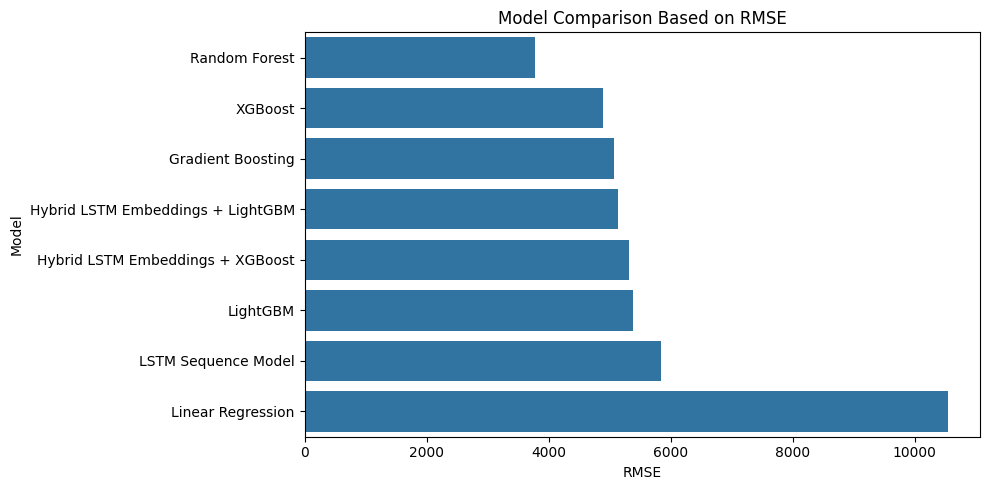

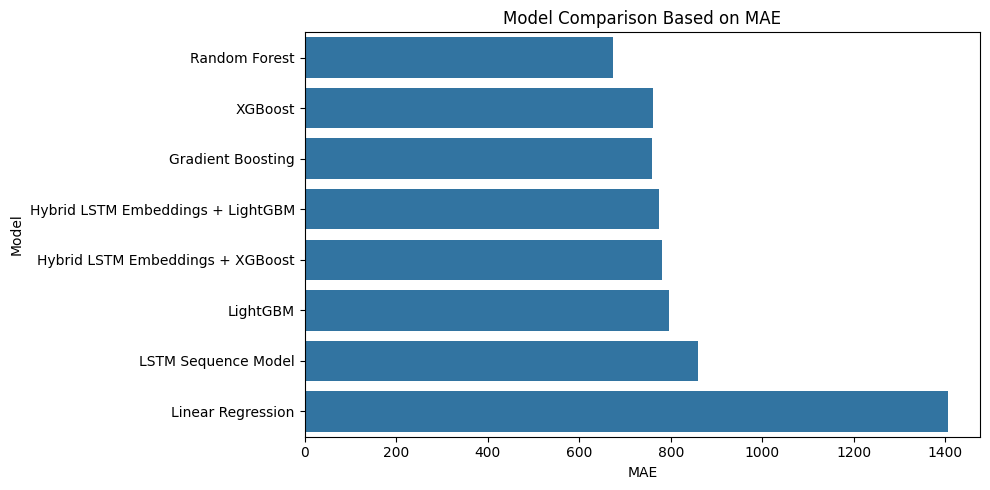

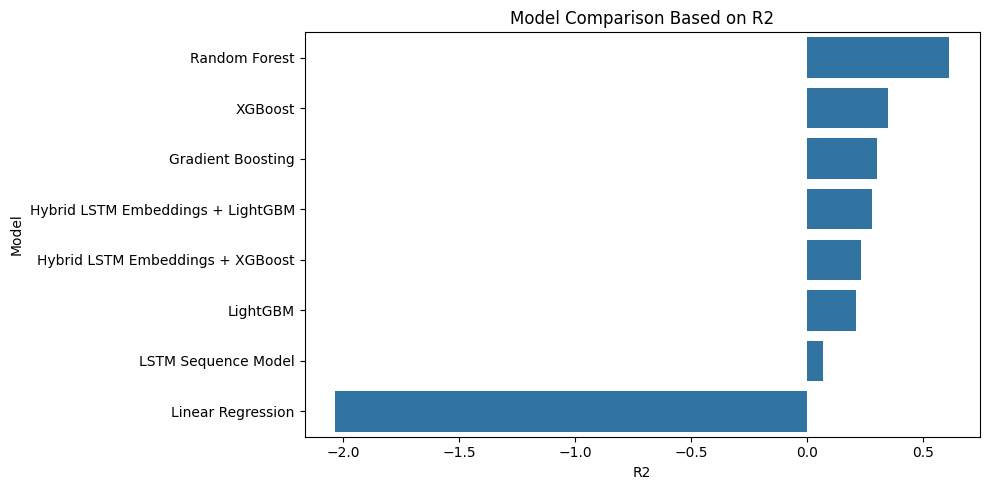

In [ ]:
#plot_results = final_results[final_results["Model"]!= "Linear Regression"]

plt.figure(figsize=(10,5))
sns.barplot(data=final_results,x="RMSE",y="Model")
plt.title("Model Comparison Based on RMSE")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=final_results,x="MAE",y="Model")
plt.title("Model Comparison Based on MAE")
plt.xlabel("MAE")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=final_results,x="R2",y="Model")
plt.title("Model Comparison Based on R2")
plt.xlabel("R2")
plt.ylabel("Model")
plt.tight_layout()
plt.show()


**17.Actual vs Predicted CLV plot**

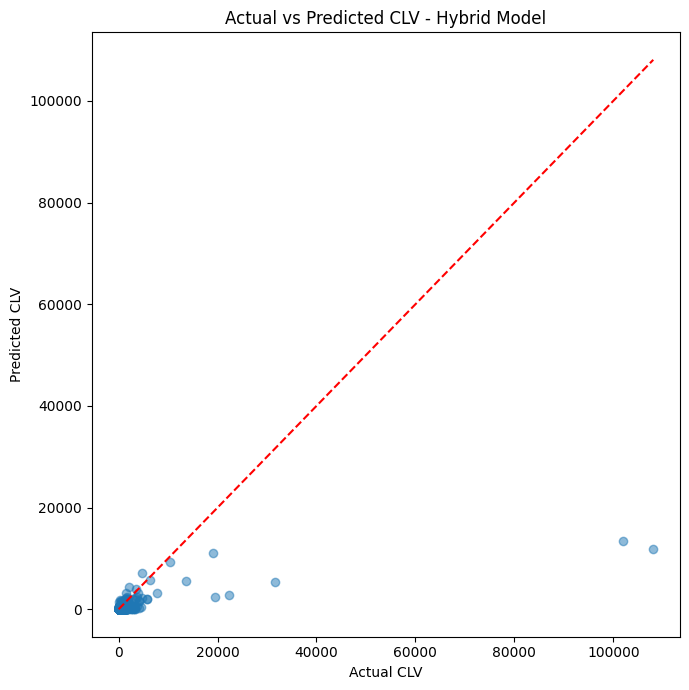

In [ ]:
y_actual=np.expm1(yh_test)
y_predicted=np.expm1(hybrid_xgb_pred)
y_predicted = np.maximum(y_predicted,0)

plt.figure(figsize=(7,7))
plt.scatter(y_actual,y_predicted,alpha=0.5)
plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")

plt.title("Actual vs Predicted CLV - Hybrid Model")
plt.plot([y_actual.min(),y_actual.max()],[y_actual.min(),y_actual.max()],"r--")
plt.tight_layout()
plt.show()


**18.Residual Error Plot**

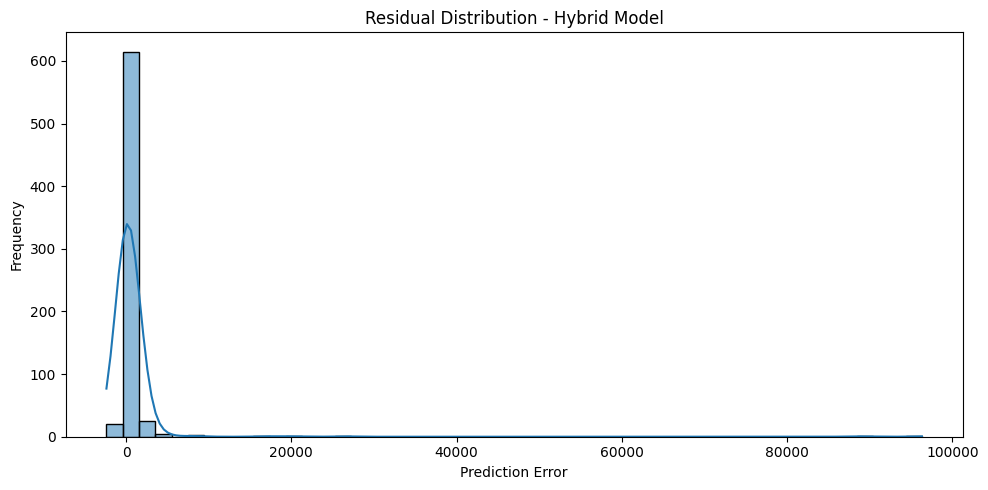

In [ ]:
residuals = y_actual - y_predicted

plt.figure(figsize=(10,5))
sns.histplot(residuals,bins=50,kde=True)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.title("Residual Distribution - Hybrid Model")
plt.tight_layout()
plt.show()




**19.Feature Importance for Hybrid Model**

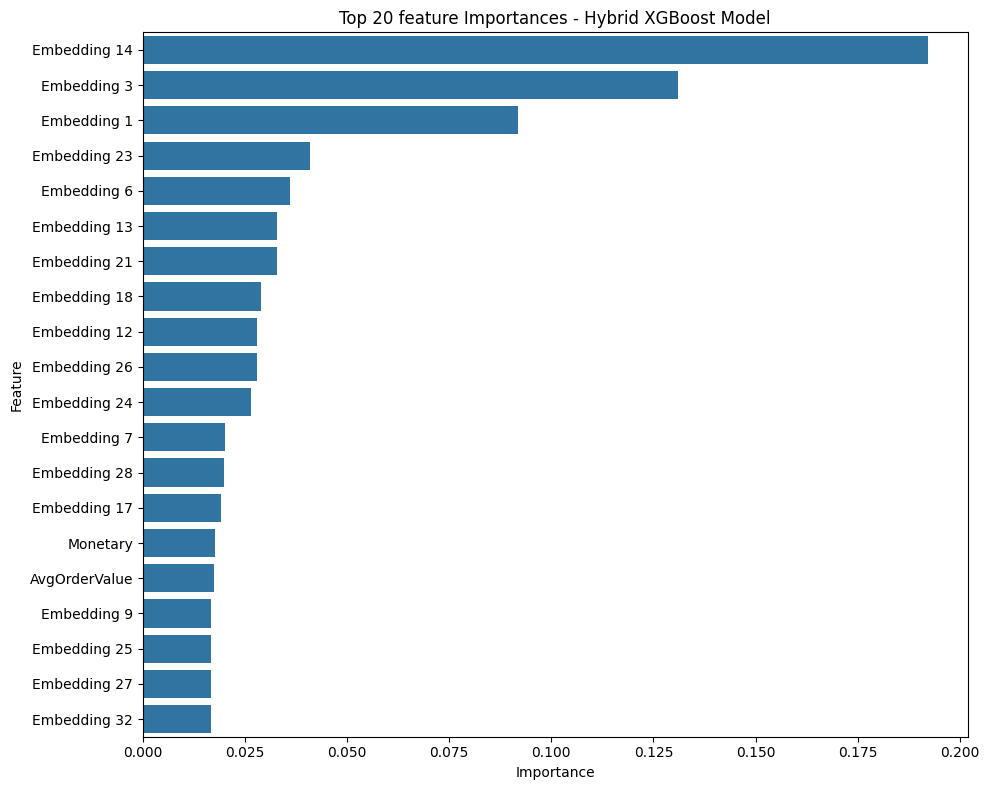

,Feature,Importance
19,Embedding 14,0.192277
8,Embedding 3,0.131113
6,Embedding 1,0.091880
28,Embedding 23,0.041039
11,Embedding 6,0.036130
18,Embedding 13,0.032951
26,Embedding 21,0.032888
23,Embedding 18,0.029021
17,Embedding 12,0.027993
31,Embedding 26,0.027860


In [ ]:
importance_df = pd.DataFrame({
    "Feature":hybrid_features,
    "Importance":hybrid_xgb.feature_importances_
}).sort_values("Importance",ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(data=importance_df.head(20),x="Importance",y="Feature")
plt.title("Top 20 feature Importances - Hybrid XGBoost Model")
plt.tight_layout()
plt.show()

importance_df.head(20)